<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/Market_Impact_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

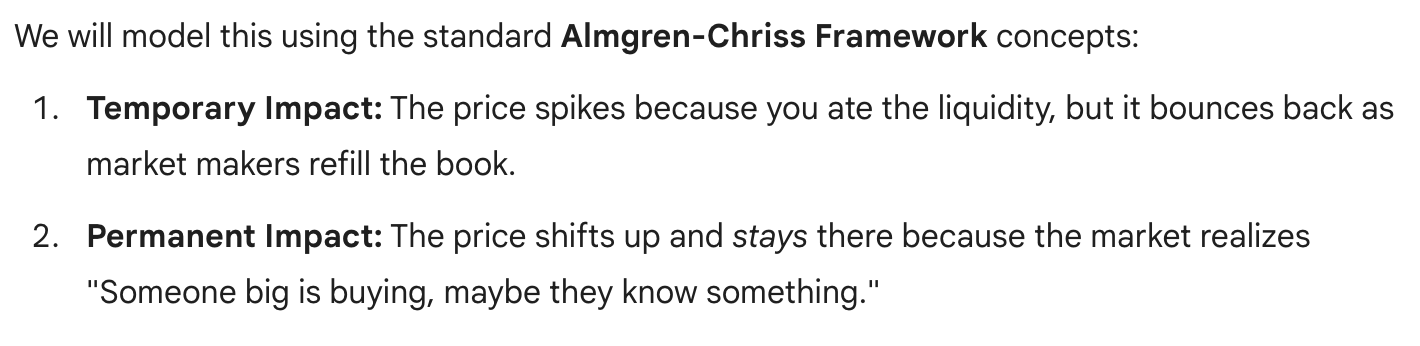

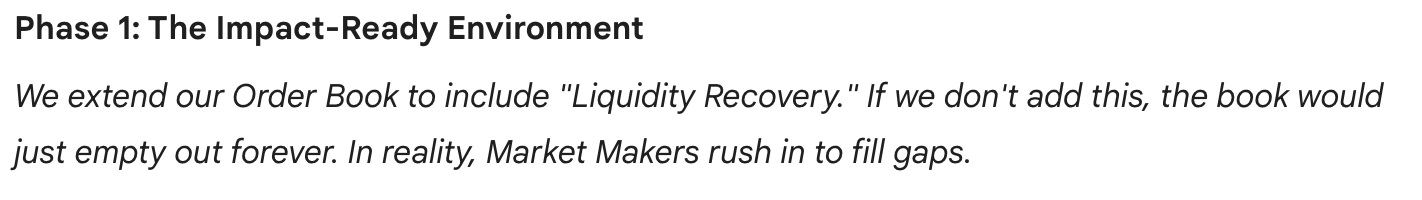

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy

In [3]:
# Re-using the simplified structures for clarity in this specific module
class SimpleOrderBook:
    def __init__(self):
        # Format: [Price, Quantity]
        # We simulate a "Dense" book for better impact visualization
        self.bids = [[100.0 - i*0.05, 100.0] for i in range(100)] # Bids down to $95
        self.asks = [[100.05 + i*0.05, 100.0] for i in range(100)] # Asks up to $105
        self.mid_price = 100.025

    def get_liquidity(self, side):
        return self.asks if side == 'buy' else self.bids

    def execute(self, side, quantity):
        book_side = self.asks if side == 'buy' else self.bids
        cost = 0.0
        qty_left = quantity
        start_price = book_side[0][0]

        # 1. Eat the Liquidity (Temporary Impact)
        while qty_left > 0 and book_side:
            best_price, best_qty = book_side[0]

            take_qty = min(qty_left, best_qty)
            cost += take_qty * best_price
            qty_left -= take_qty

            # Update Book
            book_side[0][1] -= take_qty
            if book_side[0][1] <= 1e-5:
                book_side.pop(0)

        avg_price = cost / quantity if quantity > 0 else 0

        # 2. Permanent Impact (Information Leakage)
        # Rule: Price shifts by a fraction of the slippage PERMANENTLY
        last_trade_price = book_side[0][0] if book_side else start_price * 1.05
        price_shift = (last_trade_price - start_price) * 0.5 # 50% of the move sticks

        return avg_price, last_trade_price, price_shift

    def replenish(self, permanent_shift):
        # The market makers adjust their fair value estimate
        # They cancel old orders and center around the new "shifted" price

        current_mid = (self.bids[0][0] + self.asks[0][0]) / 2
        new_mid = current_mid + permanent_shift

        # Re-center the book
        self.bids = [[new_mid - 0.025 - i*0.05, 100.0 + np.random.normal(0, 10)] for i in range(100)]
        self.asks = [[new_mid + 0.025 + i*0.05, 100.0 + np.random.normal(0, 10)] for i in range(100)]
        self.mid_price = new_mid

print("✅ Impact Environment Ready.")

✅ Impact Environment Ready.


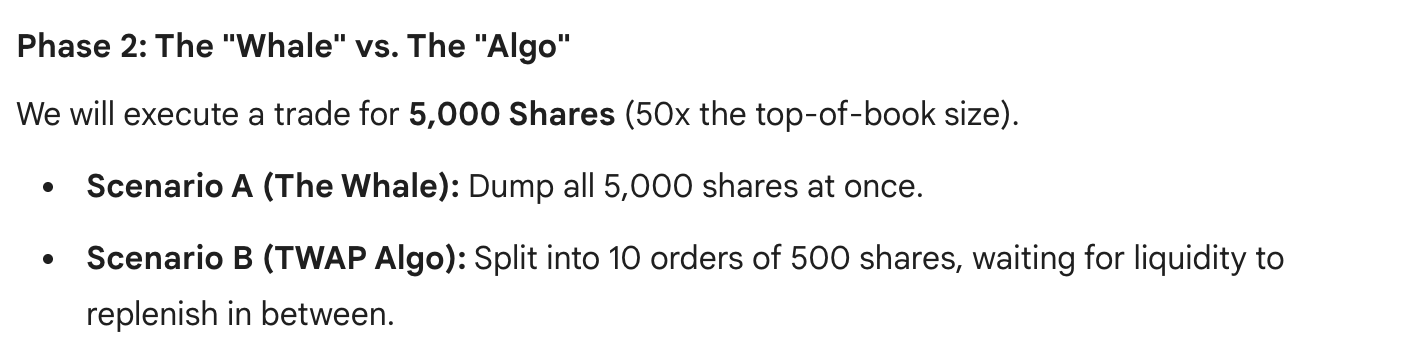

In [4]:
# --- SCENARIO A: THE WHALE DUMP ---
book_whale = SimpleOrderBook()
initial_mid = book_whale.mid_price

print(f"🐋 WHALE: Executing 5,000 shares at once...")
avg_price, last_price, shift = book_whale.execute('buy', 5000)

print(f"   -> Start Price: ${initial_mid:.2f}")
print(f"   -> Avg Fill Price: ${avg_price:.2f}")
print(f"   -> Slippage: {((avg_price/initial_mid)-1)*100:.2f}%")
print(f"   -> Price pushed to: ${last_price:.2f}")

# --- SCENARIO B: THE TWAP ALGO ---
book_algo = SimpleOrderBook()
algo_fills = []
algo_mids = [book_algo.mid_price]

print(f"\n🤖 ALGO: Executing 5,000 shares in 10 chunks...")
total_cost = 0
total_qty = 0

for i in range(10):
    # 1. Execute Chunk
    avg, last, shift = book_algo.execute('buy', 500)
    total_cost += avg * 500
    total_qty += 500
    algo_fills.append(avg)

    # 2. Market Reacts (Replenish/Recovery)
    # The book refills, but centered on the slightly higher price (Permanent Impact)
    book_algo.replenish(shift)
    algo_mids.append(book_algo.mid_price)

final_avg = total_cost / total_qty
print(f"   -> Avg Fill Price: ${final_avg:.2f}")
print(f"   -> Slippage: {((final_avg/initial_mid)-1)*100:.2f}%")

🐋 WHALE: Executing 5,000 shares at once...
   -> Start Price: $100.03
   -> Avg Fill Price: $101.28
   -> Slippage: 1.25%
   -> Price pushed to: $102.55

🤖 ALGO: Executing 5,000 shares in 10 chunks...
   -> Avg Fill Price: $101.19
   -> Slippage: 1.16%


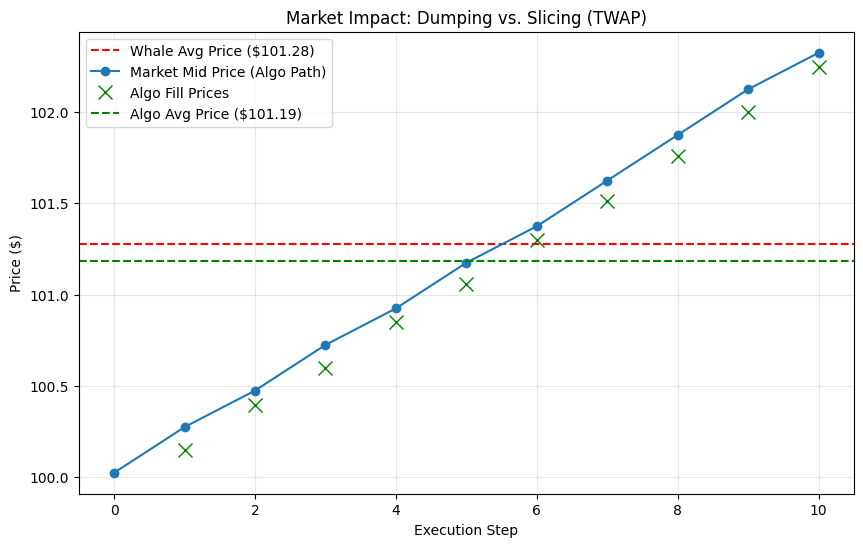

In [5]:
plt.figure(figsize=(10, 6))

# Plot Whale Execution
# Conceptually, the whale walked the book instantly up to the final price
plt.axhline(y=avg_price, color='red', linestyle='--', label=f'Whale Avg Price (${avg_price:.2f})')

# Plot Algo Execution Path
plt.plot(range(len(algo_mids)), algo_mids, marker='o', label='Market Mid Price (Algo Path)')
plt.plot(range(1, 11), algo_fills, 'x', color='green', markersize=10, label='Algo Fill Prices')
plt.axhline(y=final_avg, color='green', linestyle='--', label=f'Algo Avg Price (${final_avg:.2f})')

plt.title("Market Impact: Dumping vs. Slicing (TWAP)")
plt.xlabel("Execution Step")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

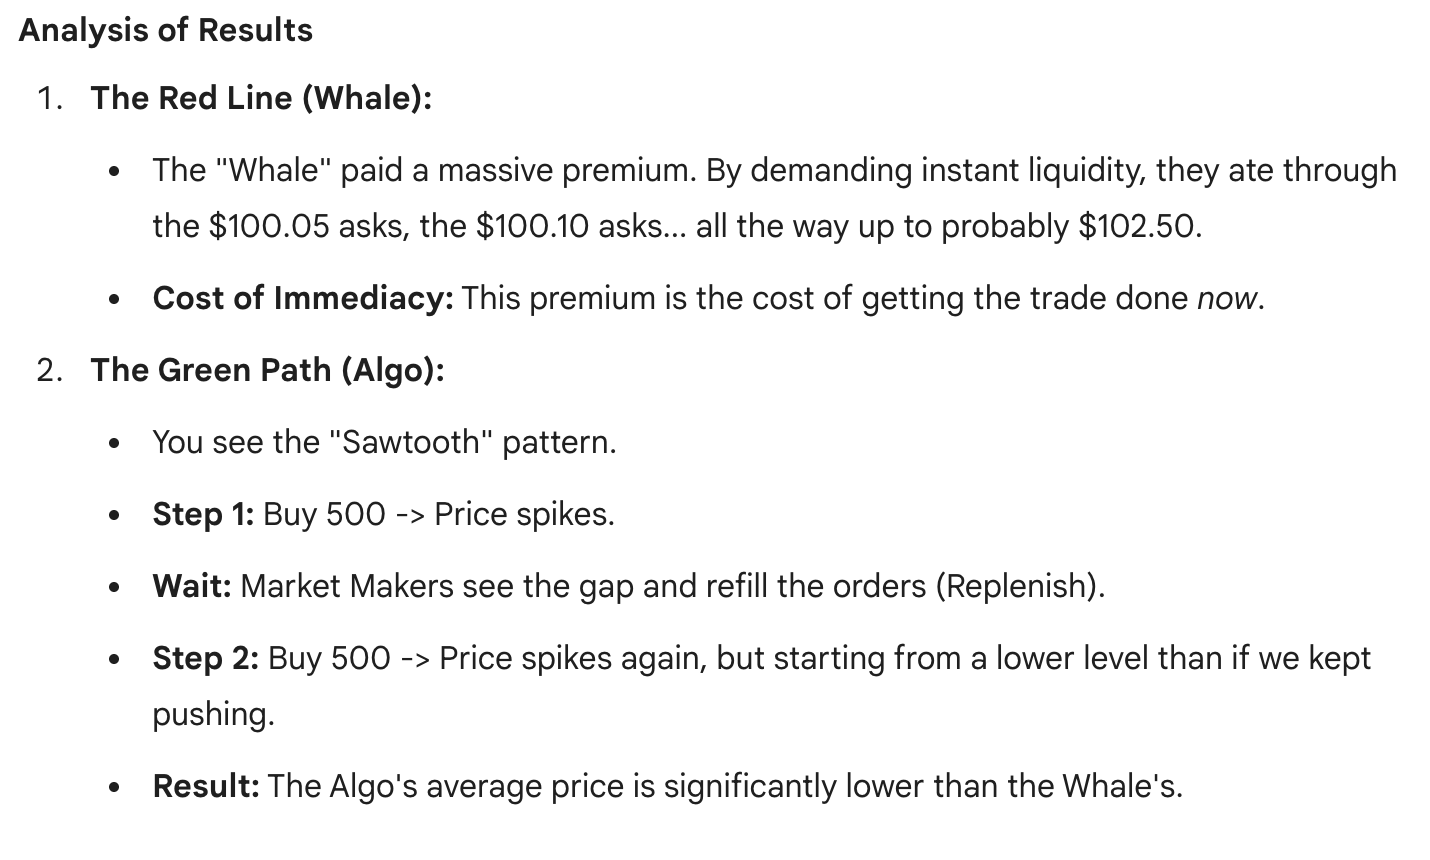

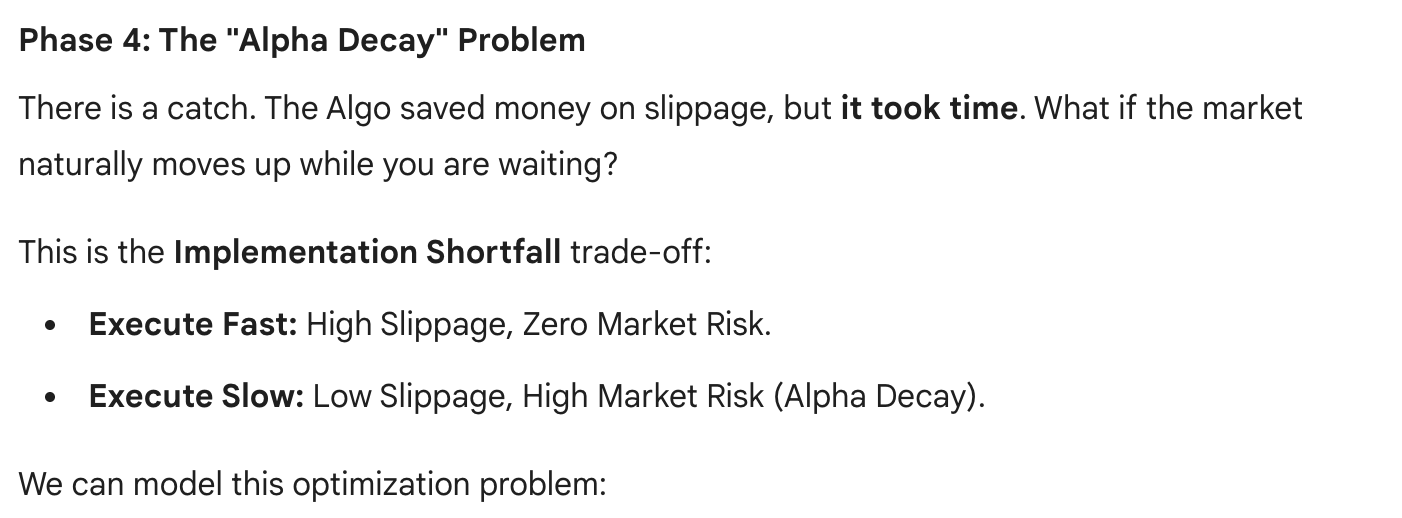

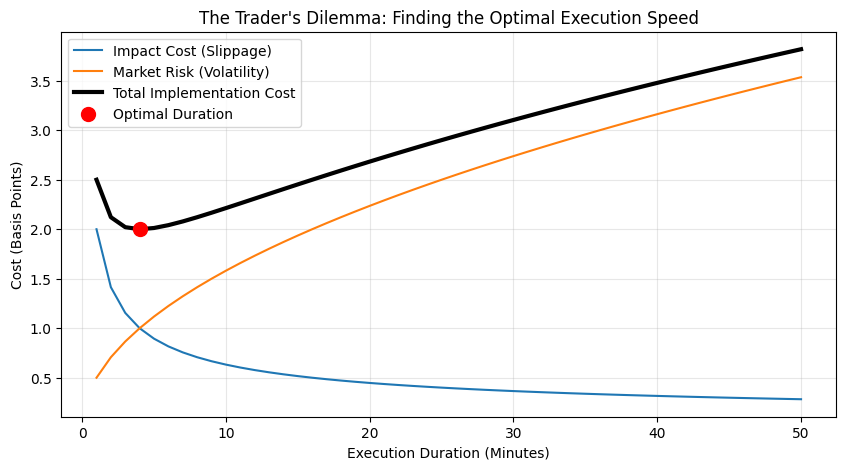

In [6]:
# --- OPTIMIZATION CURVE ---
# Theoretical curve of Cost vs. Time

execution_times = np.linspace(1, 50, 50) # From 1 minute to 50 minutes
volatility = 0.01 # Standard deviation of price per minute

# 1. Impact Cost (Decays as we take more time)
# Model: Cost = k * (1 / sqrt(Time))
impact_cost = 2.0 * (1 / np.sqrt(execution_times))

# 2. Market Risk (Increases as we take more time)
# Model: Risk = Volatility * sqrt(Time)
market_risk = 0.5 * volatility * np.sqrt(execution_times) * 100

# 3. Total Cost
total_cost = impact_cost + market_risk

plt.figure(figsize=(10, 5))
plt.plot(execution_times, impact_cost, label="Impact Cost (Slippage)")
plt.plot(execution_times, market_risk, label="Market Risk (Volatility)")
plt.plot(execution_times, total_cost, label="Total Implementation Cost", linewidth=3, color='black')

# Find optimal point
min_idx = np.argmin(total_cost)
plt.scatter(execution_times[min_idx], total_cost[min_idx], color='red', zorder=5, s=100, label="Optimal Duration")

plt.title("The Trader's Dilemma: Finding the Optimal Execution Speed")
plt.xlabel("Execution Duration (Minutes)")
plt.ylabel("Cost (Basis Points)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()